In [1]:
# %% Cell 1: imports
import sys, torch, numpy as np
sys.path.append('..'); sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from backbones.backbones import get_resnet50, get_vit, get_clip, extract_all_features
from img_prep.make_subset import load_stl10
from img_prep.transforms import (to_common_224, resnet_normalize, vit_normalize, clip_normalize,
                                  grayscale_transform, translate_transform,
                                  patch_shuffle_transform, make_patch_permutations)
from img_prep.adain import AdaINStyleTransfer
from img_prep.make_cue_conflicts import build_conflict_plan
from evaluations.evaluate_bias import extract_features_from_tensors
from evaluations.feature_similarity import cosine_stability

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from pathlib import Path

set_seed(6304)
device = "cuda" if torch.cuda.is_available() else "cpu"
Path("../../report/figures").mkdir(parents=True, exist_ok=True)

In [2]:
# %% Cell 2: data + backbones
subset_ids = load_results("../results/subset_ids.json")
test_idx = subset_ids["test_subset_indices"]
test_ds = load_stl10(split='test')
class_names = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

labels = np.array([test_ds[i][1] for i in test_idx])
clean_imgs = torch.stack([to_common_224(test_ds[i][0]) for i in test_idx])

resnet, _ = get_resnet50(); vit, _ = get_vit(); clip_model, _ = get_clip()
backbones_info = [("resnet50", resnet, resnet_normalize, "resnet_or_vit"),
                  ("vit_b16", vit, vit_normalize, "resnet_or_vit"),
                  ("clip", clip_model, clip_normalize, "clip")]

In [3]:
# %% Cell 3: build every transformed image set (paired 1:1 with clean)
perms = load_results("../results/patch_permutations.json")["permutations"]

transformed = {}
transformed["grayscale"] = torch.stack([grayscale_transform(x) for x in clean_imgs])
transformed["patch_shuffle"] = torch.stack([patch_shuffle_transform(x, perms[i])
                                             for i, x in enumerate(clean_imgs)])
transformed["translation_32"] = torch.stack([translate_transform(x, 32, 'right')
                                              for x in clean_imgs])


adain = AdaINStyleTransfer("../../datasets/adain_weights/vgg_normalised.pth",
                            "../../datasets/adain_weights/decoder.pth", device=device)
plan = build_conflict_plan(labels, class_names, n_per_direction=20, seed=6304)
cc_content = torch.stack([clean_imgs[p["content_pos"]] for p in plan])
cc_style   = torch.stack([clean_imgs[p["style_pos"]]   for p in plan])
cc_labels  = np.array([p["shape_label"] for p in plan])

outs = []
for i in range(0, len(plan), 32):
    outs.append(adain(cc_content[i:i+32], cc_style[i:i+32], alpha=1.0).cpu())
cc_transformed = torch.cat(outs)
del outs; torch.cuda.empty_cache()

print({k: tuple(v.shape) for k, v in transformed.items()}, cc_transformed.shape)

{'grayscale': (500, 3, 224, 224), 'patch_shuffle': (500, 3, 224, 224), 'translation_32': (500, 3, 224, 224)} torch.Size([200, 3, 224, 224])


In [4]:
# %% Cell 4: cosine stability for every (backbone, intervention)
results = {"step": "representation_analysis", "seed": 6304, "cosine_stability": {}}
feature_store = {}   

for name, model, norm_fn, mtype in backbones_info:
    f_clean = extract_features_from_tensors(model, clean_imgs, norm_fn, model_type=mtype, device=device)
    feature_store[(name, "clean")] = f_clean
    results["cosine_stability"][name] = {}

    for interv, imgs in transformed.items():
        f_t = extract_features_from_tensors(model, imgs, norm_fn, model_type=mtype, device=device)
        mean_cos, _ = cosine_stability(f_clean, f_t)
        results["cosine_stability"][name][interv] = mean_cos
        feature_store[(name, interv)] = f_t
        torch.cuda.empty_cache()

    
    f_cc_clean = extract_features_from_tensors(model, cc_content, norm_fn, model_type=mtype, device=device)
    f_cc_t = extract_features_from_tensors(model, cc_transformed, norm_fn, model_type=mtype, device=device)
    mean_cos, _ = cosine_stability(f_cc_clean, f_cc_t)
    results["cosine_stability"][name]["cue_conflict"] = mean_cos
    torch.cuda.empty_cache()

    print(name, {k: round(v, 4) for k, v in results["cosine_stability"][name].items()})

resnet50 {'grayscale': 0.7979, 'patch_shuffle': 0.6935, 'translation_32': 0.9393, 'cue_conflict': 0.245}
vit_b16 {'grayscale': 0.7316, 'patch_shuffle': 0.6263, 'translation_32': 0.9513, 'cue_conflict': 0.2269}
clip {'grayscale': 0.8877, 'patch_shuffle': 0.7466, 'translation_32': 0.9631, 'cue_conflict': 0.675}


c:\Users\javai\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\javai\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\javai\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\javai\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

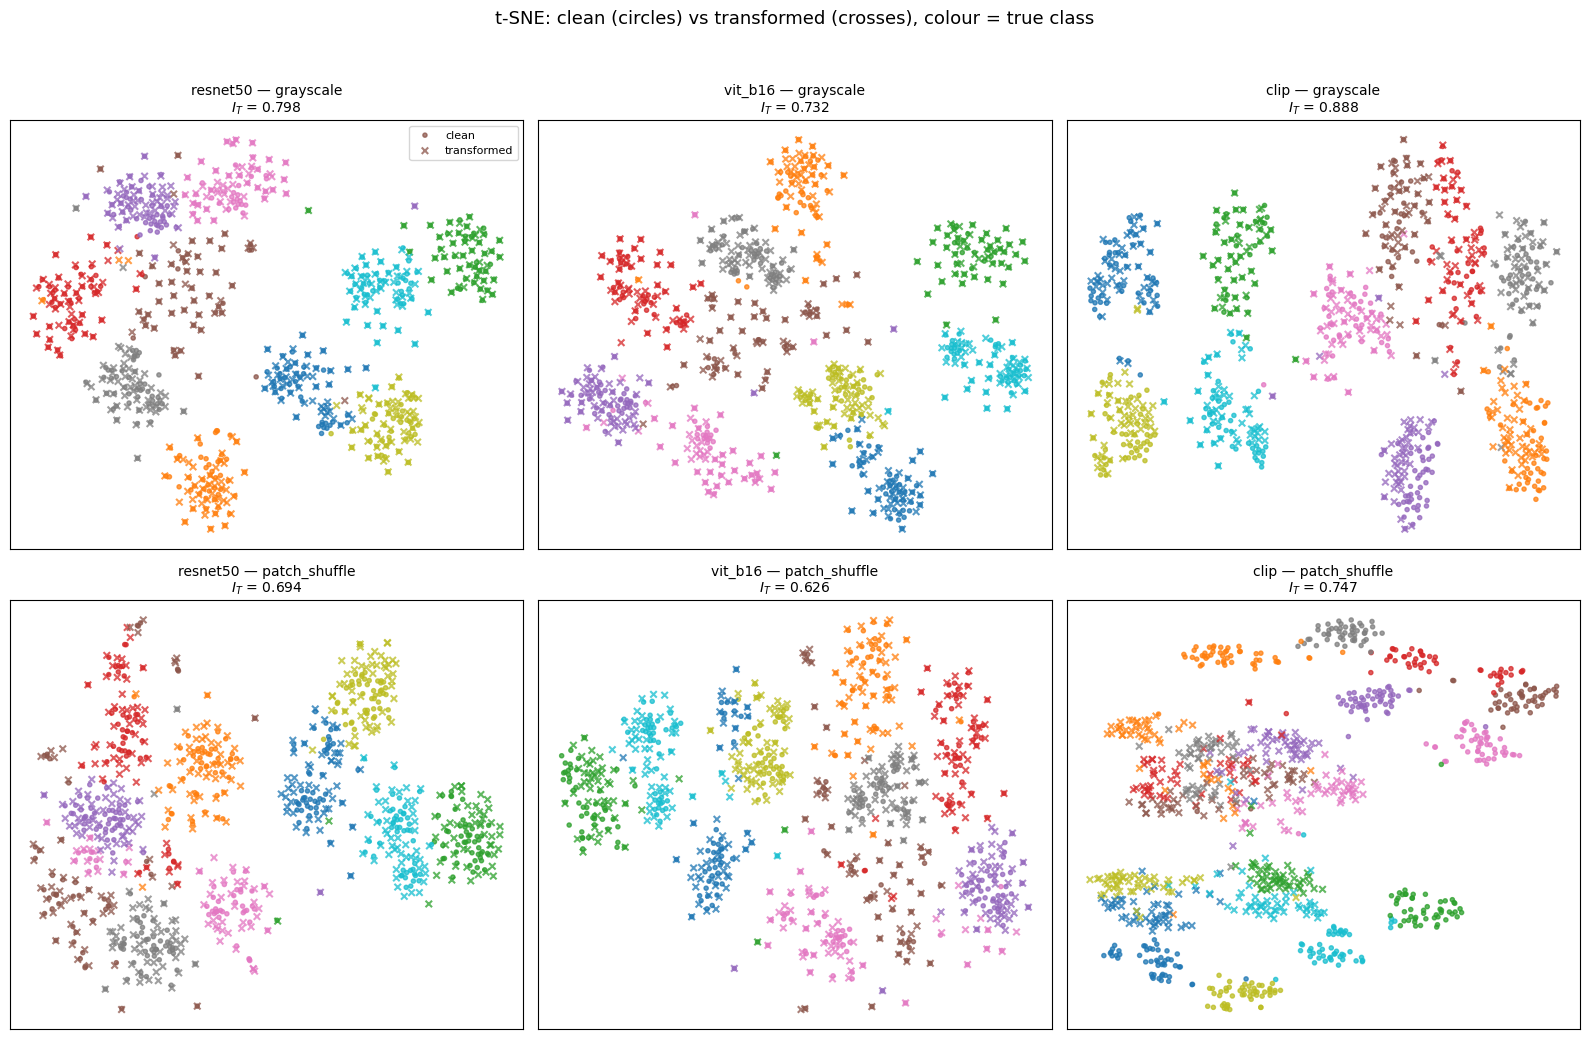

c:\Users\javai\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\javai\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\javai\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\javai\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\javai\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\javai\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for paralle

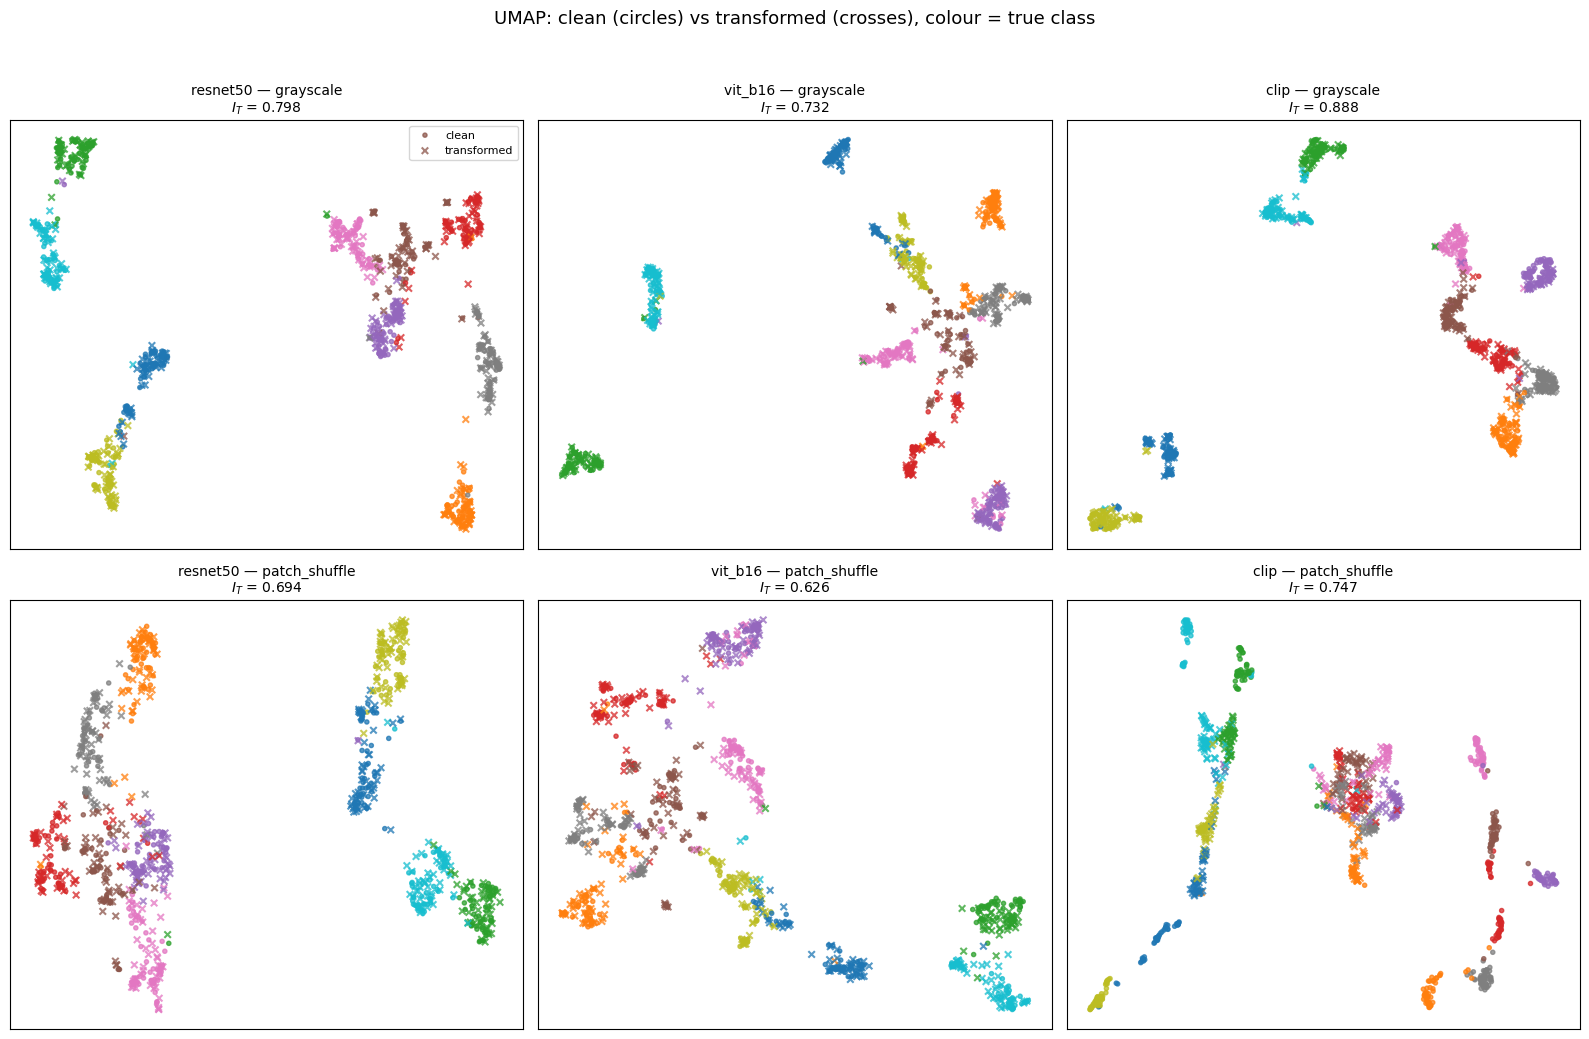

In [5]:
# %% Cell 5: t-SNE and UMAP, side by side
# Settings fixed and reported, as the manual requires.
TSNE_KW = dict(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=6304)
UMAP_KW = dict(n_components=2, n_neighbors=15, min_dist=0.1, random_state=6304)
results["visualization_settings"] = {"tsne": {k: str(v) for k, v in TSNE_KW.items()},
                                      "umap": {k: str(v) for k, v in UMAP_KW.items()}}

show_interventions = ["grayscale", "patch_shuffle"]   #both extremes

for method_name, make_proj in [("t-SNE", lambda: TSNE(**TSNE_KW)),
                                ("UMAP",  lambda: umap.UMAP(**UMAP_KW))]:
    fig, axes = plt.subplots(len(show_interventions), 3, figsize=(16, 5.2 * len(show_interventions)))
    for r, interv in enumerate(show_interventions):
        for c, (name, _, _, _) in enumerate(backbones_info):
            f_clean = feature_store[(name, "clean")]
            f_t = feature_store[(name, interv)]
            
            combined = np.vstack([f_clean, f_t])
            proj = make_proj().fit_transform(combined)
            n = len(f_clean)

            ax = axes[r, c]
            ax.scatter(proj[:n, 0], proj[:n, 1], c=labels, cmap='tab10', s=9,
                        marker='o', alpha=0.75, label='clean')
            ax.scatter(proj[n:, 0], proj[n:, 1], c=labels, cmap='tab10', s=22,
                        marker='x', alpha=0.75, label='transformed')
            cos = results["cosine_stability"][name][interv]
            ax.set_title(f"{name} — {interv}\n$I_T$ = {cos:.3f}", fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0 and c == 0: ax.legend(fontsize=8, loc='best')
    fig.suptitle(f"{method_name}: clean (circles) vs transformed (crosses), colour = true class",
                 fontsize=13, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fname = f"representation_{method_name.lower().replace('-','')}.png"
    fig.savefig(f"../../report/figures/{fname}", dpi=180, bbox_inches='tight')
    plt.show()

In [6]:
# %% Cell 6: save
save_results(results, "../results/representation_analysis.json")
print(results["cosine_stability"])

{'resnet50': {'grayscale': 0.7979374176669061, 'patch_shuffle': 0.6935052120381321, 'translation_32': 0.9392843432509076, 'cue_conflict': 0.24504338615238233}, 'vit_b16': {'grayscale': 0.7316273172833926, 'patch_shuffle': 0.6262675175452881, 'translation_32': 0.9512508841415477, 'cue_conflict': 0.22692698764857752}, 'clip': {'grayscale': 0.8876952701395974, 'patch_shuffle': 0.746633516694541, 'translation_32': 0.9630835176804023, 'cue_conflict': 0.6749752145890432}}
